In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

import joblib

In [2]:
df = pd.read_csv("Churn_Modelling.csv")

In [3]:
print("First 5 rows:")
display(df.head())

First 5 rows:


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
print("Dataset Shape:")
print(df.shape)

Dataset Shape:
(10000, 14)


In [5]:
print("\nColumn Names:")
print(df.columns)



Column Names:
Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')


In [6]:
print("\nDataset Information:")
df.info()


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [7]:
print("\nStatistical Summary:")
display(df.describe())


Statistical Summary:


,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [8]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


In [9]:
print("\nDuplicate Rows:")
print(df.duplicated().sum())


Duplicate Rows:
0


In [10]:
df = df.drop(["RowNumber", "CustomerId", "Surname"], axis=1)

In [11]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [12]:
print("New Dataset Shape:", df.shape)
print("Columns:")
print(df.columns)

New Dataset Shape: (10000, 11)
Columns:
Index(['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance',
       'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
       'Exited'],
      dtype='object')


Feature Engineering

In [16]:
df["BalanceSalaryRatio"] = df["Balance"] / (df["EstimatedSalary"] + 1)

In [17]:
df[["Balance", "EstimatedSalary", "BalanceSalaryRatio"]].head()

,Balance,EstimatedSalary,BalanceSalaryRatio
0,0.00,101348.88,0.000000
1,83807.86,112542.58,0.744670
2,159660.80,113931.57,1.401362
3,0.00,93826.63,0.000000
4,125510.82,79084.10,1.587035


In [19]:
df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[0, 30, 40, 50, 100],
    labels=["Young", "Adult", "Middle_Age", "Senior"]
)

In [20]:
df[["Age", "AgeGroup"]].head(10)

,Age,AgeGroup
0,42,Middle_Age
1,41,Middle_Age
2,42,Middle_Age
3,39,Adult
4,43,Middle_Age
5,44,Middle_Age
6,50,Middle_Age
7,29,Young
8,44,Middle_Age
9,27,Young


In [22]:
print(df.shape)

(10000, 13)


In [23]:
print("Geography:")
print(df["Geography"].value_counts())

print("\nGender:")
print(df["Gender"].value_counts())

print("\nAgeGroup:")
print(df["AgeGroup"].value_counts())

Geography:
Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

Gender:
Gender
Male      5457
Female    4543
Name: count, dtype: int64

AgeGroup:
AgeGroup
Adult         4451
Middle_Age    2320
Young         1968
Senior        1261
Name: count, dtype: int64


In [24]:
df = pd.get_dummies(
    df,
    columns=["Geography", "Gender", "AgeGroup"],
    drop_first=True
)

In [25]:
print(df.head())
print("\nNew Shape:", df.shape)
print("\nColumns:")
print(df.columns)

   CreditScore  Age  Tenure    Balance  NumOfProducts  HasCrCard  \
0          619   42       2       0.00              1          1   
1          608   41       1   83807.86              1          0   
2          502   42       8  159660.80              3          1   
3          699   39       1       0.00              2          0   
4          850   43       2  125510.82              1          1   

   IsActiveMember  EstimatedSalary  Exited  BalanceSalaryRatio  \
0               1        101348.88       1            0.000000   
1               1        112542.58       0            0.744670   
2               0        113931.57       1            1.401362   
3               0         93826.63       0            0.000000   
4               1         79084.10       0            1.587035   

   Geography_Germany  Geography_Spain  Gender_Male  AgeGroup_Adult  \
0              False            False        False           False   
1              False             True        False    

In [26]:
print(df.dtypes)

CreditScore              int64
Age                      int64
Tenure                   int64
Balance                float64
NumOfProducts            int64
HasCrCard                int64
IsActiveMember           int64
EstimatedSalary        float64
Exited                   int64
BalanceSalaryRatio     float64
Geography_Germany         bool
Geography_Spain           bool
Gender_Male               bool
AgeGroup_Adult            bool
AgeGroup_Middle_Age       bool
AgeGroup_Senior           bool
dtype: object


Feature Selection

In [27]:
X = df.drop("Exited", axis=1)
y = df["Exited"]

In [28]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (10000, 15)
y shape: (10000,)


In [29]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X, y)

RandomForestClassifier(random_state=42)

In [30]:
feature_importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(feature_importance)

Age                    0.162270
CreditScore            0.125334
EstimatedSalary        0.124814
NumOfProducts          0.121487
Balance                0.106367
BalanceSalaryRatio     0.095449
Tenure                 0.074988
IsActiveMember         0.051729
AgeGroup_Senior        0.032024
Geography_Germany      0.025152
Gender_Male            0.018662
HasCrCard              0.018190
AgeGroup_Middle_Age    0.017919
Geography_Spain        0.014253
AgeGroup_Adult         0.011363
dtype: float64


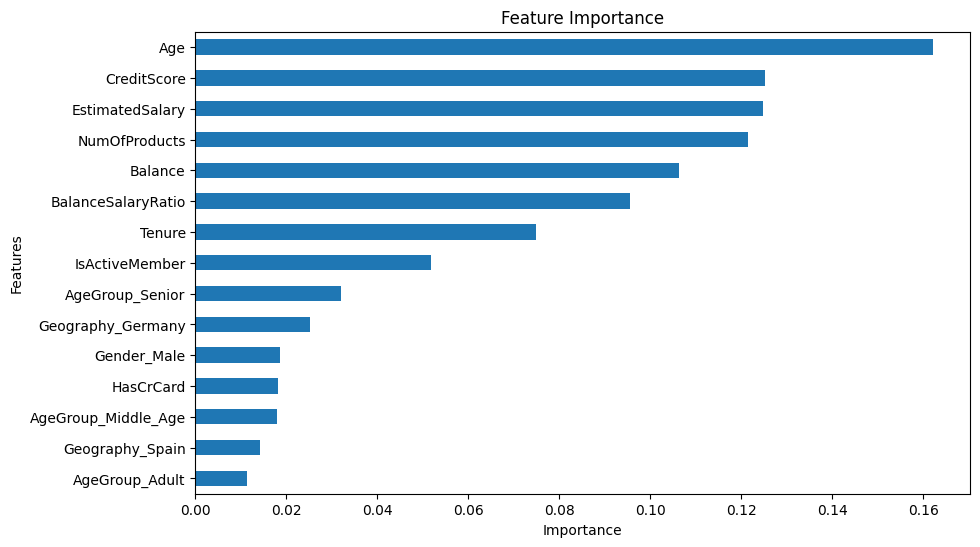

In [31]:
plt.figure(figsize=(10, 6))

feature_importance.sort_values().plot(kind="barh")

plt.title("Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.show()

In [32]:
X = X.astype(int)

In [33]:
print(X.dtypes)

CreditScore            int64
Age                    int64
Tenure                 int64
Balance                int64
NumOfProducts          int64
HasCrCard              int64
IsActiveMember         int64
EstimatedSalary        int64
BalanceSalaryRatio     int64
Geography_Germany      int64
Geography_Spain        int64
Gender_Male            int64
AgeGroup_Adult         int64
AgeGroup_Middle_Age    int64
AgeGroup_Senior        int64
dtype: object


Train/Test Split

In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [36]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (8000, 15)
X_test: (2000, 15)
y_train: (8000,)
y_test: (2000,)


Data Scaling

In [37]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [39]:
print(X_train_scaled.shape)
print(X_test_scaled.shape)

(8000, 15)
(2000, 15)


Model 1: Random Forest

In [40]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [41]:
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [42]:
rf_pred = rf_model.predict(X_test)

In [43]:
rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)
print("Random Forest Accuracy (%):", rf_accuracy * 100)

Random Forest Accuracy: 0.861
Random Forest Accuracy (%): 86.1


In [44]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.87      0.97      0.92      1593
           1       0.80      0.43      0.55       407

    accuracy                           0.86      2000
   macro avg       0.83      0.70      0.74      2000
weighted avg       0.85      0.86      0.84      2000



Model 2: Support Vector Machine (SVM)

In [45]:
svm_model = SVC(
    random_state=42
)

In [46]:
svm_model.fit(X_train_scaled, y_train)

SVC(random_state=42)

In [47]:
svm_pred = svm_model.predict(X_test_scaled)

In [48]:
svm_accuracy = accuracy_score(y_test, svm_pred)

print("SVM Accuracy:", svm_accuracy)
print("SVM Accuracy (%):", svm_accuracy * 100)

SVM Accuracy: 0.861
SVM Accuracy (%): 86.1


In [49]:
print(classification_report(y_test, svm_pred))

              precision    recall  f1-score   support

           0       0.87      0.97      0.92      1593
           1       0.79      0.43      0.56       407

    accuracy                           0.86      2000
   macro avg       0.83      0.70      0.74      2000
weighted avg       0.85      0.86      0.84      2000



Model 3: Gradient Boosting

In [50]:
gb_model = GradientBoostingClassifier(
    random_state=42
)

In [51]:
gb_model.fit(X_train, y_train)

GradientBoostingClassifier(random_state=42)

In [52]:
gb_pred = gb_model.predict(X_test)

In [53]:
gb_accuracy = accuracy_score(y_test, gb_pred)

print("Gradient Boosting Accuracy:", gb_accuracy)
print("Gradient Boosting Accuracy (%):", gb_accuracy * 100)

Gradient Boosting Accuracy: 0.871
Gradient Boosting Accuracy (%): 87.1


In [54]:
print(classification_report(y_test, gb_pred))

              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1593
           1       0.80      0.49      0.61       407

    accuracy                           0.87      2000
   macro avg       0.84      0.73      0.77      2000
weighted avg       0.86      0.87      0.86      2000



Model 4: Decision Tree

In [55]:
dt_model = DecisionTreeClassifier(
    random_state=42
)

In [56]:
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [57]:
dt_pred = dt_model.predict(X_test)

In [58]:
dt_accuracy = accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy:", dt_accuracy)
print("Decision Tree Accuracy (%):", dt_accuracy * 100)

Decision Tree Accuracy: 0.779
Decision Tree Accuracy (%): 77.9


In [59]:
print(classification_report(y_test, dt_pred))

              precision    recall  f1-score   support

           0       0.87      0.85      0.86      1593
           1       0.46      0.49      0.47       407

    accuracy                           0.78      2000
   macro avg       0.66      0.67      0.67      2000
weighted avg       0.78      0.78      0.78      2000



Compare all 4 models

In [60]:
model_comparison = pd.DataFrame({
    "Model": [
        "Random Forest",
        "SVM",
        "Gradient Boosting",
        "Decision Tree"
    ],
    "Accuracy": [
        rf_accuracy,
        svm_accuracy,
        gb_accuracy,
        dt_accuracy
    ]
})

model_comparison["Accuracy (%)"] = model_comparison["Accuracy"] * 100

display(model_comparison.sort_values(
    by="Accuracy",
    ascending=False
))

,Model,Accuracy,Accuracy (%)
2,Gradient Boosting,0.871,87.1
0,Random Forest,0.861,86.1
1,SVM,0.861,86.1
3,Decision Tree,0.779,77.9


Cross Validation

In [61]:

models = {
    "Random Forest": rf_model,
    "SVM": svm_model,
    "Gradient Boosting": gb_model,
    "Decision Tree": dt_model
}

cv_results = {}

for name, model in models.items():
    if name == "SVM":
        scores = cross_val_score(
            model,
            X_train_scaled,
            y_train,
            cv=5,
            scoring="accuracy"
        )
    else:
        scores = cross_val_score(
            model,
            X_train,
            y_train,
            cv=5,
            scoring="accuracy"
        )

    cv_results[name] = scores.mean()
    print(name, "CV Accuracy:", scores.mean())

Random Forest CV Accuracy: 0.858375
SVM CV Accuracy: 0.854875
Gradient Boosting CV Accuracy: 0.8638750000000002
Decision Tree CV Accuracy: 0.792


Hyperparameter Tuning

In [62]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 150],
    "learning_rate": [0.05, 0.1],
    "max_depth": [2, 3]
}

grid_search = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest CV Accuracy:")
print(grid_search.best_score_)

Best Parameters:
{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}

Best CV Accuracy:
0.8638750000000002


In [63]:
best_gb_model = grid_search.best_estimator_

best_gb_pred = best_gb_model.predict(X_test)

best_gb_accuracy = accuracy_score(y_test, best_gb_pred)

print("Tuned Gradient Boosting Accuracy:", best_gb_accuracy)
print("Tuned Gradient Boosting Accuracy (%):", best_gb_accuracy * 100)

print("\nClassification Report:")
print(classification_report(y_test, best_gb_pred))

Tuned Gradient Boosting Accuracy: 0.871
Tuned Gradient Boosting Accuracy (%): 87.1

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1593
           1       0.80      0.49      0.61       407

    accuracy                           0.87      2000
   macro avg       0.84      0.73      0.77      2000
weighted avg       0.86      0.87      0.86      2000



Feature Importance Analysis

In [64]:
feature_importance_gb = pd.Series(
    best_gb_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print("Gradient Boosting Feature Importance:")
print(feature_importance_gb)

Gradient Boosting Feature Importance:
Age                    0.366369
NumOfProducts          0.299800
IsActiveMember         0.113926
Balance                0.085146
Geography_Germany      0.055617
AgeGroup_Middle_Age    0.021963
CreditScore            0.019006
EstimatedSalary        0.015478
Gender_Male            0.013155
Tenure                 0.004154
BalanceSalaryRatio     0.003734
AgeGroup_Adult         0.000823
HasCrCard              0.000518
Geography_Spain        0.000308
AgeGroup_Senior        0.000002
dtype: float64


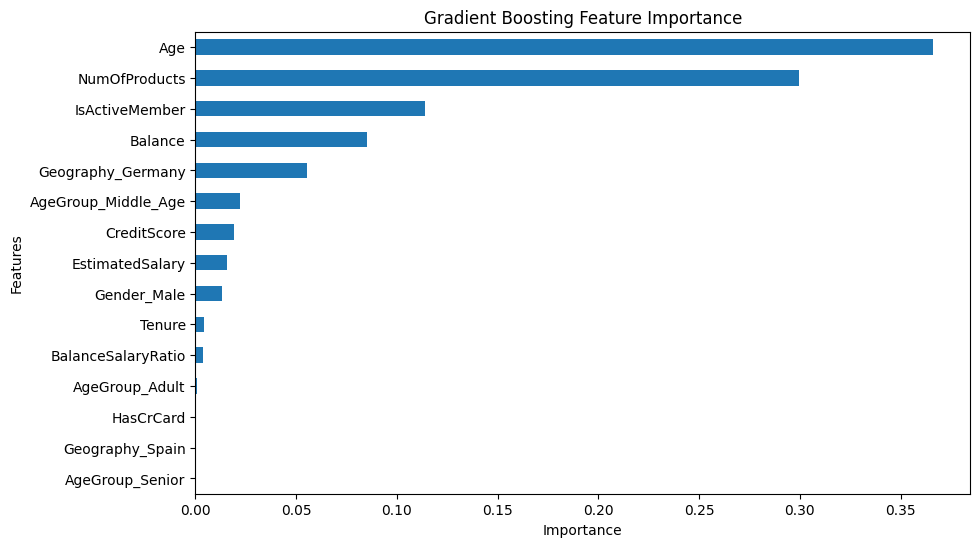

In [66]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

feature_importance_gb.sort_values().plot(kind="barh")

plt.title("Gradient Boosting Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.show()

Save the Best Model

In [67]:
import joblib

# Save the best model
joblib.dump(best_gb_model, "best_gradient_boosting_model.pkl")

# Save the scaler
joblib.dump(scaler, "scaler.pkl")

print("Best model saved successfully!")
print("Scaler saved successfully!")

Best model saved successfully!
Scaler saved successfully!


In [68]:
import joblib

loaded_model = joblib.load("best_gradient_boosting_model.pkl")
loaded_scaler = joblib.load("scaler.pkl")

print("Model loaded successfully!")
print("Scaler loaded successfully!")

Model loaded successfully!
Scaler loaded successfully!
